### What's in this notebook
#### Trained a Decision Tree Regressor on a sample dataset

### Important parameters for a Decision Tree Regressor
#### 'criterion': Grading formula to measure split quality. "squared_error" by default (can also be "absolute_error", "friedman_mse", or "poisson").
#### 'splitter': Strategy to choose the split at each node. "best" by default (tests all thresholds, "random" is faster).
#### 'max_depth': Maximum levels/questions deep the tree can go. None by default (grows infinitely until perfectly pure).
#### 'min_samples_split': Minimum rows needed in a group to allow another split. 2 by default.
#### 'min_samples_leaf': Minimum rows required to form a final prediction leaf. 1 by default.
#### 'max_features': Number of columns to look at when deciding a split. None by default (looks at all columns).
#### 'max_leaf_nodes': Maximum total number of final leaves allowed. None by default (infinite leaves).
#### 'ccp_alpha': Aggressiveness of pruning (chopping off weak branches after growth to prevent overfitting). 0.0 by default (no pruning).

In [1]:
# required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# creating a dataset

In [4]:
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

In [5]:
X

array([[0.02761059],
       [0.10292247],
       [0.12709563],
       [0.17194261],
       [0.22613644],
       [0.23225206],
       [0.29041806],
       [0.31779175],
       [0.32525796],
       [0.37022326],
       [0.37275322],
       [0.44246251],
       [0.48836057],
       [0.53945713],
       [0.5793453 ],
       [0.59797123],
       [0.61019117],
       [0.6974693 ],
       [0.70462112],
       [0.7799726 ],
       [0.7800932 ],
       [0.85262062],
       [0.90912484],
       [0.91702255],
       [0.92427228],
       [0.97991431],
       [0.99357841],
       [0.99836891],
       [1.06169555],
       [1.29389991],
       [1.35674516],
       [1.40467255],
       [1.4561457 ],
       [1.46072324],
       [1.52121121],
       [1.52306885],
       [1.55491161],
       [1.55855538],
       [1.62591661],
       [1.62665165],
       [1.65449012],
       [1.78376663],
       [1.79232864],
       [1.83180922],
       [1.87270059],
       [1.94338645],
       [2.13770509],
       [2.159

In [6]:
y

array([ 0.03631178,  0.07284012,  0.13592982, -0.02766026,  0.20224683,
        0.26588096,  0.43414221,  0.26064263,  0.23870388,  0.31164787,
        0.45572117,  0.46104124,  0.41620271,  0.56499704,  0.55718394,
        0.6598314 ,  0.50281884,  0.60951383,  0.60853441,  0.55690845,
        0.7329577 ,  0.77911291,  0.78947765,  0.77033558,  0.65664551,
        0.78838511,  0.80371261,  0.76036086,  0.85705457,  1.00231359,
        1.16579698,  1.00369093,  1.01918985,  0.98650348,  0.80689379,
        0.99620987,  1.00589686,  1.24624929,  0.97924517,  1.02859523,
        0.99302854,  0.86053961,  1.08984419,  1.04132239,  1.0338752 ,
        0.84044885,  0.98384451,  0.69135109,  0.86673316,  0.97769835,
        0.60459397,  0.56640353,  0.62758133,  0.48963842,  0.36014357,
        0.51060126,  0.38874848,  0.46251339,  0.30486974,  0.48395778,
        0.10023179,  0.11930091,  0.22910896,  0.01251215,  0.12642772,
        0.21294948, -0.13564894, -0.02771489, -0.14419806, -0.19

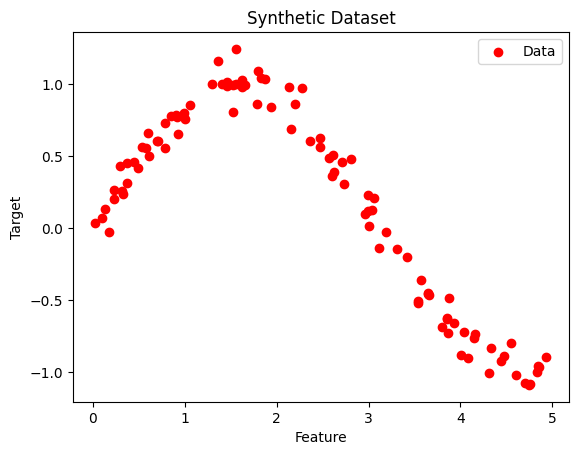

In [8]:
# plotting X against y
plt.scatter(X, y, color='red', label='Data')
plt.title("Synthetic Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

In [10]:
# splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
# initializing our tree
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

In [14]:
# training
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [15]:
y_pred = regressor.predict(X_test)

In [16]:
# checking mse
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.0151


In [17]:
# let's visualize that how well the decision tree fits the data and capture underlying patterns

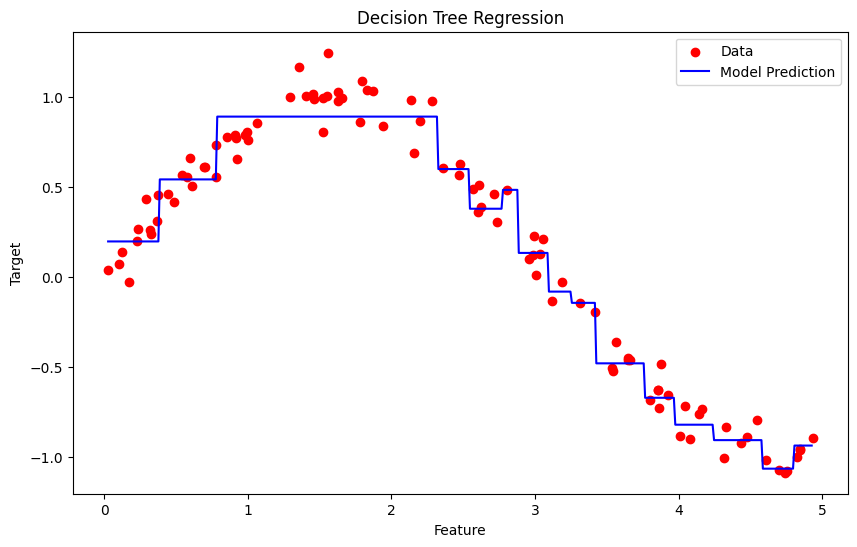

In [21]:
X_grid = np.arange(X.min().item(), X.max().item(), 0.01)[:, np.newaxis]
y_grid_pred = regressor.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

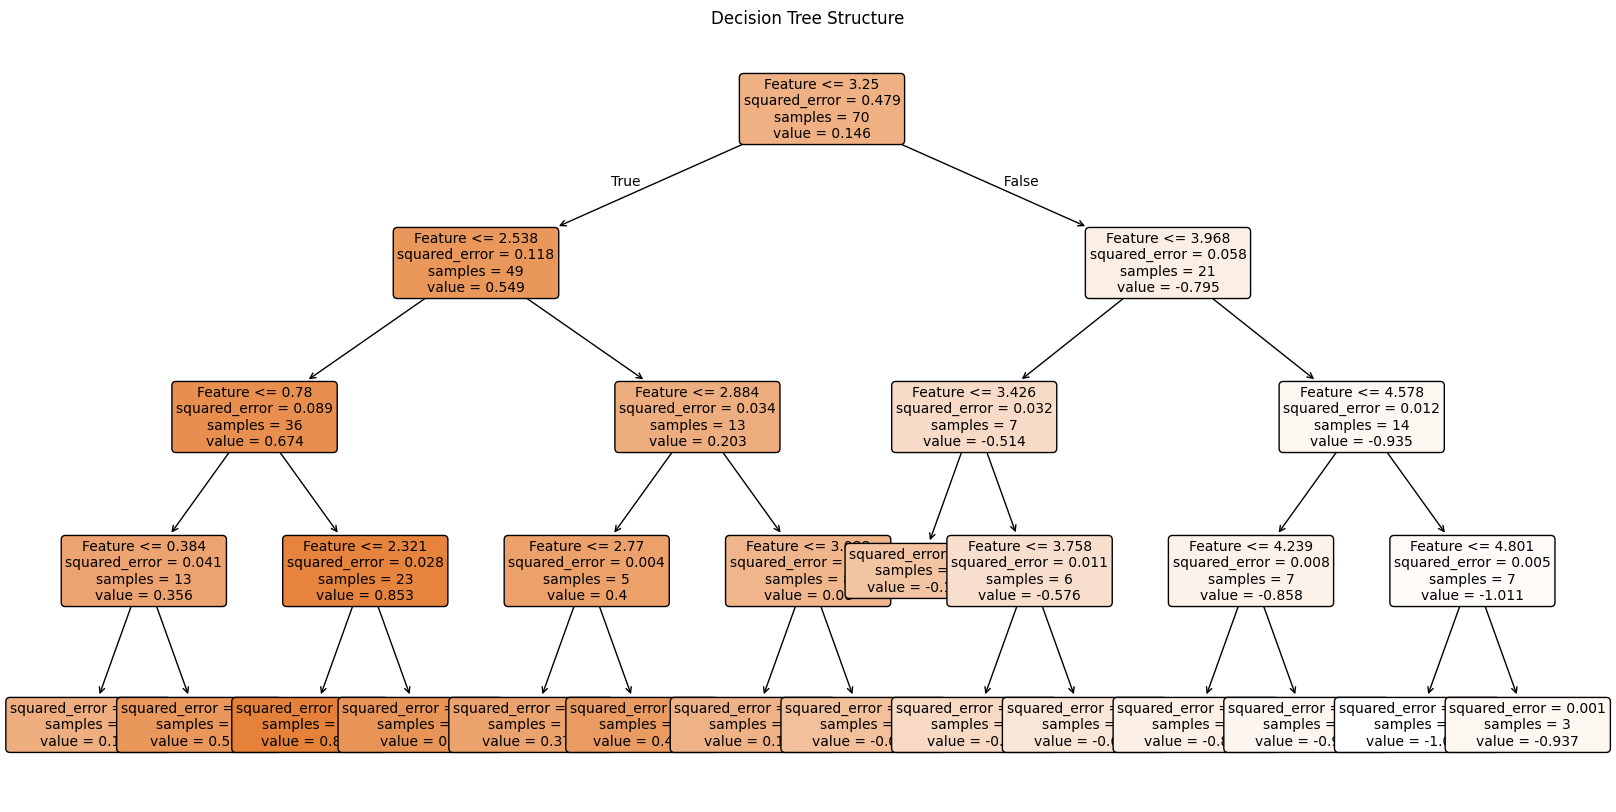

In [19]:
# visualization of the tree and conditions
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(
    regressor,
    feature_names=["Feature"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()